# Klein et al. (2017) – Droplet Barcoding for Single-Cell Transcriptomics Applied to Embryonic Stem Cells

The original paper can be found here: https://www.sciencedirect.com/science/article/pii/S0092867415005000

__Abstract__: It has long been the dream of biologists to map gene expression at the single-cell level. With such data one might track heterogeneous cell sub-populations, and infer regulatory relationships between genes and pathways. Recently, RNA sequencing has achieved single-cell resolution. What is limiting is an effective way to routinely isolate and process large numbers of individual cells for quantitative in-depth sequencing. We have developed a high-throughput droplet-microfluidic approach for barcoding the RNA from thousands of individual cells for subsequent analysis by next-generation sequencing. The method shows a surprisingly low noise profile and is readily adaptable to other sequencing-based assays. We analyzed mouse embryonic stem cells, revealing in detail the population structure and the heterogeneous onset of differentiation after leukemia inhibitory factor (LIF) withdrawal. The reproducibility of these high-throughput single-cell data allowed us to deconstruct cell populations and infer gene expression relationships.

Klein et al. analyze 2,717 single cells. The 4 classes in which they mention are experimental conditions/timepoints:

What the 4 classes are
- 0 days (baseline mESCs, +LIF)
- 2 days after LIF withdrawal
- 4 days after LIF withdrawal
- 7 days after LIF withdrawal

Klein profiled mESCs before and after LIF withdrawal to study early differentiation dynamics; GEO lists data for baseline ES cells and LIF− at days 2, 4, 7, which are the four-condition split many benchmarks (incl. scMINER) use.

## 0. Imports & Set-Up:

In [1]:
import multiprocessing
import os, random

from pathlib import Path

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import pandas as pd

import anndata as ad

import matplotlib.pyplot as plt

from carve import CARVE

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [3]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [5]:
from functions import (
    align_labels, gamma_quantile_approx, gap_statistic, davies_bouldin_inv
)

The following cell defines a custom `LeidenClustering` class, providing a scikit-learn style interface to the Leiden community detection algorithm. This approach enables clustering of tabular data by first constructing a k-nearest neighbor (kNN) graph and then applying Leiden for community detection.

The custom `LeidenClustering` class:
- Accepts standard sklearn parameters (`n_clusters`, `n_neighbors`, `resolution`, `random_state`).
- Builds an undirected kNN graph from the input data.
- Runs Leiden via the `leidenalg` package on the constructed graph.
- Optionally relabels clusters to match the requested number of clusters (`n_clusters`), mapping the largest clusters to consecutive labels.
- Is compatible with sklearn workflows (`fit`, `fit_predict`).

This wrapper is used for benchmarking Leiden clustering alongside other sklearn algorithms below.

In [6]:
from sklearn.base import BaseEstimator
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors

class LeidenClustering(BaseEstimator, ClusterMixin):
    """
    Wrapper for Leiden community detection algorithm with sklearn interface.
    Clusters tabular data by building a k-nearest neighbor graph and running Leiden.

    Parameters:
        n_clusters (int): Desired number of clusters (approximate, Leiden may not match exactly).
        n_neighbors (int): Number of neighbors for graph construction (default: 10).
        resolution (float): Resolution parameter for Leiden (higher = more clusters, default: 1.0).
        random_state (int or None): Random seed.
    """
    def __init__(self, n_clusters=None, n_neighbors=10, resolution=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.n_neighbors = n_neighbors
        self.resolution = resolution
        self.random_state = random_state

    def fit(self, X, y=None):
        # Build kNN graph
        knn = NearestNeighbors(n_neighbors=self.n_neighbors + 1, metric='euclidean')
        knn.fit(X)
        knn_graph = knn.kneighbors_graph(X, mode='connectivity')
        sources, targets = knn_graph.nonzero()
        edges = list(zip(sources.tolist(), targets.tolist()))

        # Create igraph graph
        g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
        g.simplify()

        # Run Leiden
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=self.resolution,
            seed=self.random_state
        )
        self.labels_ = np.array(partition.membership)

        # Optionally, relabel to match n_clusters if specified
        if self.n_clusters is not None and len(np.unique(self.labels_)) != self.n_clusters:
            # Map largest clusters to 0..n_clusters-1, rest to -1
            counts = np.bincount(self.labels_)
            top = np.argsort(counts)[::-1][:self.n_clusters]
            mapping = {old: new for new, old in enumerate(top)}
            self.labels_ = np.array([mapping.get(l, -1) for l in self.labels_])

        return self

    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_

---

## 1. Pre-Process the Data

In [7]:
DATA_DIR = Path("../data/klein")
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}

def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")
    
    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    
    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]
    
    return df  # genes × cells

read four matrices (genes × cells):

In [8]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [9]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [10]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i+1:04d}" for i in range(df.shape[1])]
    return df

d0 = add_prefix(d0, "d0"); d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4"); d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1] +
    ["d2"] * d2.shape[1] +
    ["d4"] * d4.shape[1] +
    ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [11]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y
adata.layers["counts"] = adata.X.copy()  # raw UMIs

print(adata)
print(adata.obs["condition"].value_counts())

AnnData object with n_obs × n_vars = 2717 × 24175
    obs: 'condition'
    layers: 'counts'
condition
d0    933
d7    798
d4    683
d2    303
Name: count, dtype: int64


---

## 2. Analyse Data

In [12]:
X = expr_gxc.T.values.astype(np.float32)
X = np.log1p(X)

print(f"X shape (cells × genes): {X.shape[0]:,} × {X.shape[1]:,}")

X shape (cells × genes): 2,717 × 24,175


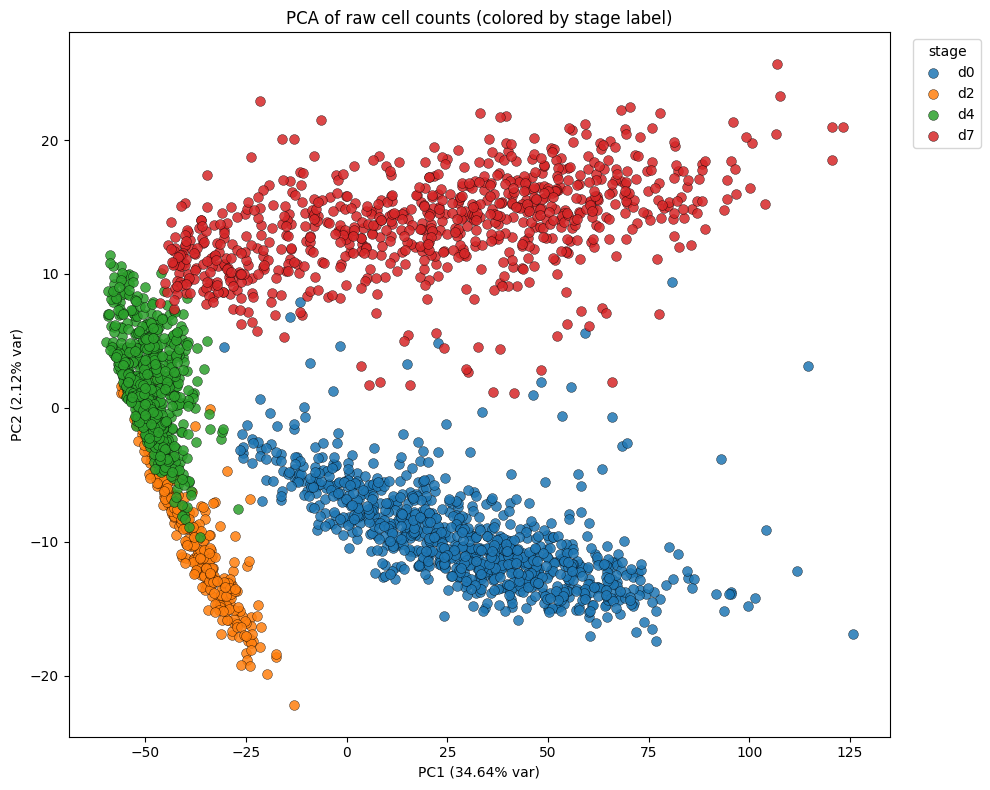

In [13]:
pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
pc_df['label'] = y.values

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of raw cell counts (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.4 Perform Clustering with "Oracle" Number of Clusters:

In [14]:
# from sklearn.model_selection import StratifiedShuffleSplit

# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_SEED)
# sub_idx = next(sss.split(X, y))[1]

# X_sub = X[sub_idx]
# y_sub = y[sub_idx]

# print("Subsampled X shape:", X_sub.shape)
# print("Subsampled y shape:", y_sub.shape)
# print("Label distribution in subsample:", pd.Series(y_sub).value_counts().head())

In [15]:
n_clusters = len(np.unique(y))

# KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X)
ari_kmeans = adjusted_rand_score(y, kmeans_labels)

# Agglomerative (Ward linkage)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg.fit_predict(X)
ari_agg = adjusted_rand_score(y, agg_labels)

# Leiden
leiden = LeidenClustering(n_clusters=n_clusters, random_state=RANDOM_SEED)
leiden_labels = leiden.fit_predict(X)
ari_leiden = adjusted_rand_score(y, leiden_labels)

# Spectral Clustering (median heuristic for gamma)
gamma = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)
spectral = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=gamma, random_state=RANDOM_SEED)
spectral_labels = spectral.fit_predict(X)
ari_spectral = adjusted_rand_score(y, spectral_labels)

print(f"ARI KMeans: {ari_kmeans:.4f}")
print(f"ARI Agglomerative (Ward): {ari_agg:.4f}")
print(f"ARI Leiden: {ari_leiden:.4f}")
print(f"ARI Spectral (gamma={gamma:.6f}): {ari_spectral:.4f}")

ARI KMeans: 0.3731
ARI Agglomerative (Ward): 0.2920
ARI Leiden: 0.3980
ARI Spectral (gamma=0.000047): 0.6608


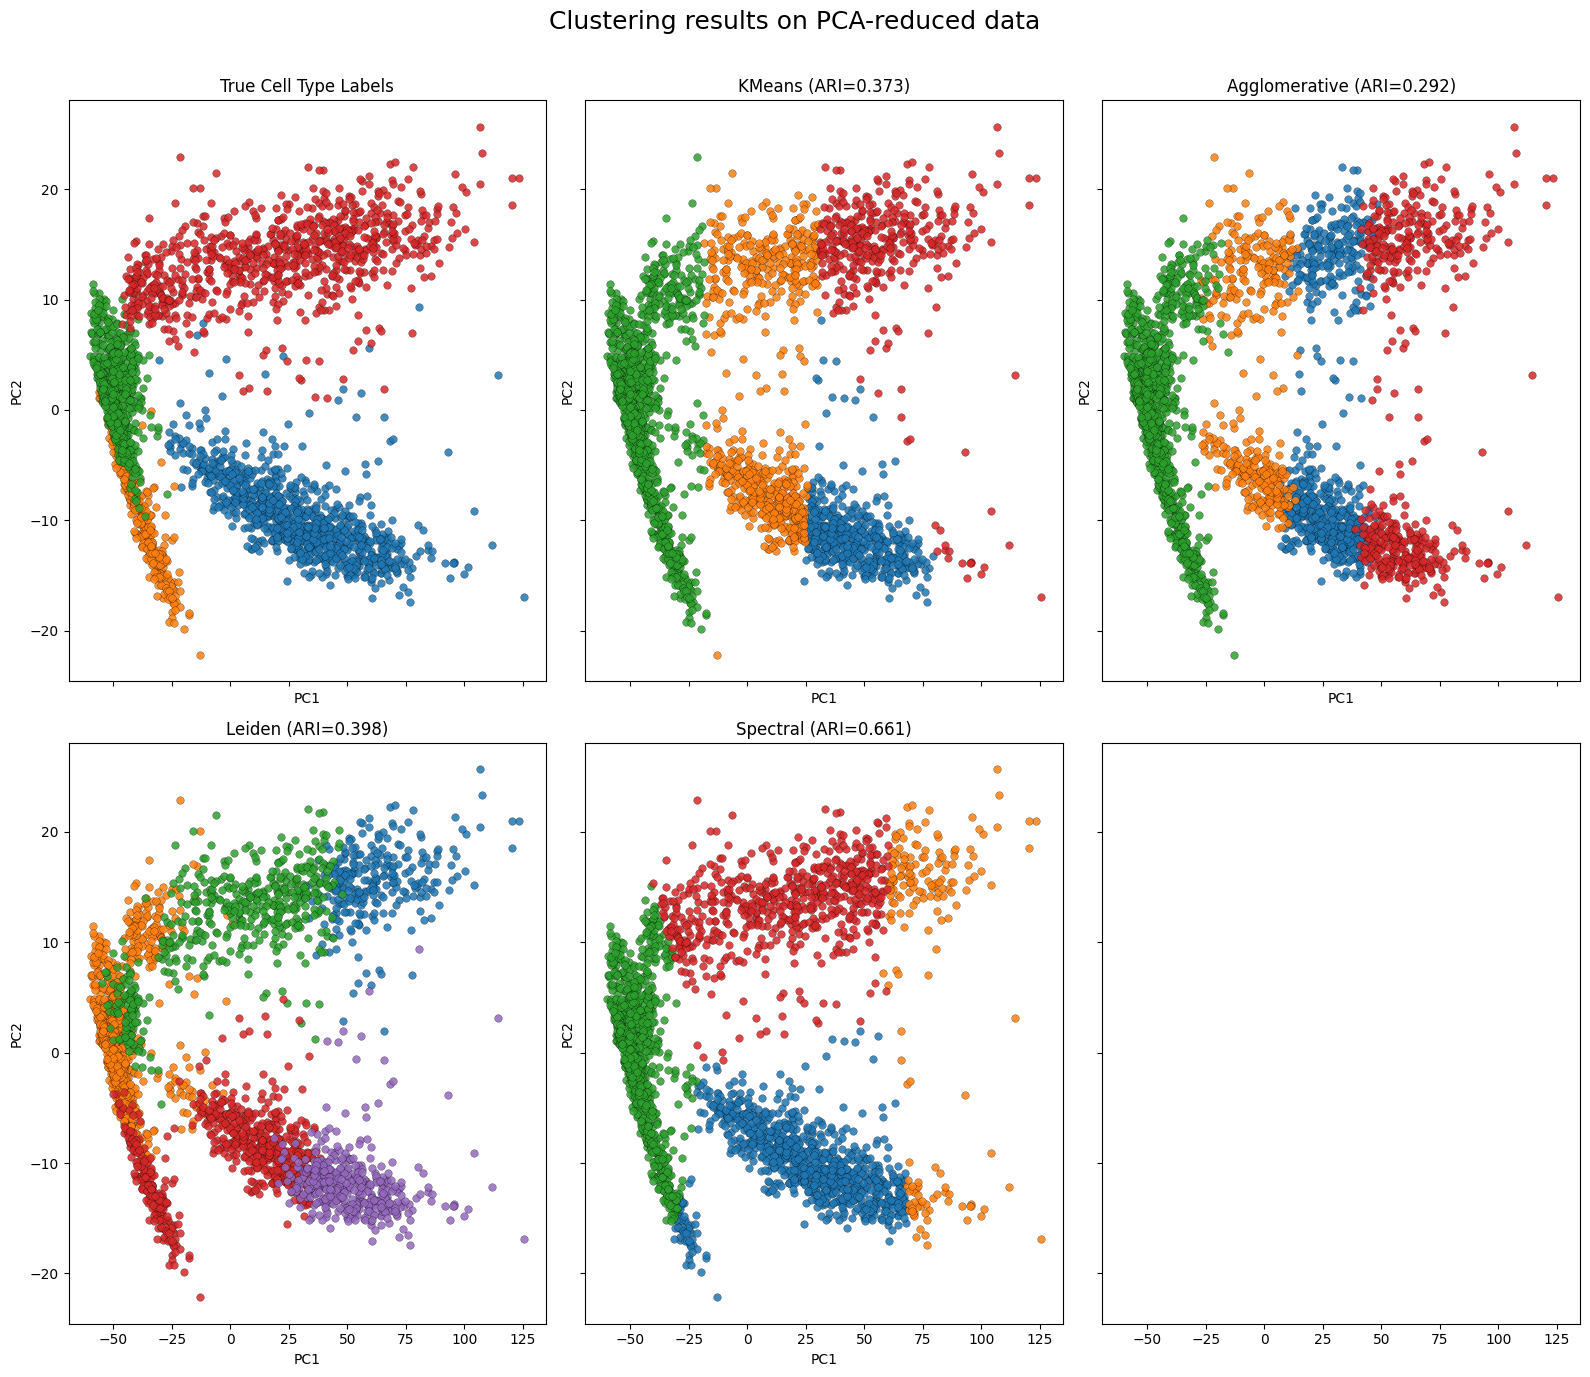

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 14), sharex=True, sharey=True)

# Plot true labels
ax_true = axes[0, 0]
for lab in pd.Categorical(y).categories:
    sel = pc_df['label'] == lab
    ax_true.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=lab)
ax_true.set_title("True Cell Type Labels")
ax_true.set_xlabel("PC1")
ax_true.set_ylabel("PC2")
# ax_true.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

titles = [
    f"KMeans (ARI={ari_kmeans:.3f})",
    f"Agglomerative (ARI={ari_agg:.3f})",
    f"Leiden (ARI={ari_leiden:.3f})",
    f"Spectral (ARI={ari_spectral:.3f})"
]
clusterings = [kmeans_labels, agg_labels, leiden_labels, spectral_labels]
aligned_clusterings = [align_labels(pd.Categorical(y).codes, labels) for labels in clusterings]

for ax, labels, title in zip(axes.flat[1:], aligned_clusterings, titles):
    for cluster in np.unique(labels):
        sel = labels == cluster
        ax.scatter(
            pc_df.loc[labels == cluster, 'PC1'],
            pc_df.loc[labels == cluster, 'PC2'],
            s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=f"Cluster {cluster}"
        )
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    # ax.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.suptitle("Clustering results on PCA-reduced data", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

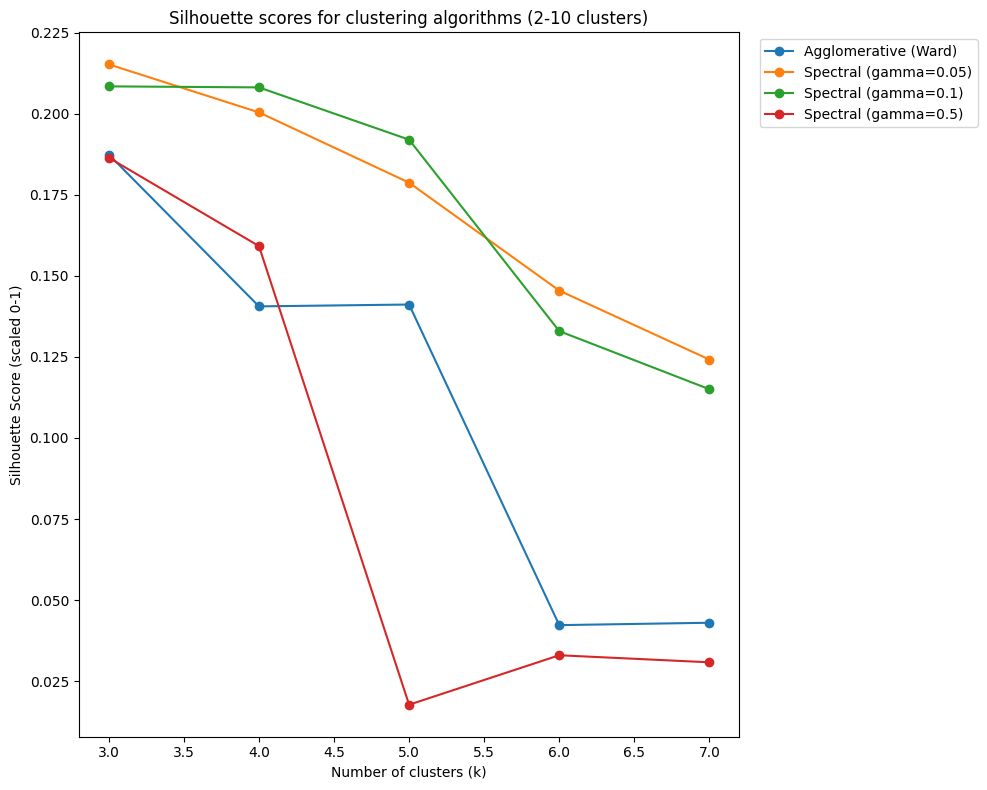

In [17]:
K = 7
ks = np.arange(3, K+1)

silhouette_scores_agg = []
silhouette_scores_spectral_005 = []
silhouette_scores_spectral_01 = []
silhouette_scores_spectral_05 = []

gamma_005 = gamma_quantile_approx(X, q=0.05, random_state=RANDOM_SEED)
gamma_01 = gamma_quantile_approx(X, q=0.1, random_state=RANDOM_SEED)
gamma_05 = gamma_quantile_approx(X, q=0.5, random_state=RANDOM_SEED)

for k in ks:
    # KMeans
    # kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    # labels_kmeans = kmeans.fit_predict(X)
    # sil_kmeans = silhouette_score(X, labels_kmeans)
    # silhouette_scores_kmeans.append(sil_kmeans)
    
    # Agglomerative (Ward)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_agg = agg.fit_predict(X)
    sil_agg = silhouette_score(X, labels_agg)
    silhouette_scores_agg.append(sil_agg)
    
    # Spectral Clustering (median heuristic for gamma)
    spectral_005 = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma_005, random_state=RANDOM_SEED)
    labels_spectral_005 = spectral_005.fit_predict(X)
    sil_spectral_005 = silhouette_score(X, labels_spectral_005)
    silhouette_scores_spectral_005.append(sil_spectral_005) 
    
    spectral_01 = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma_01, random_state=RANDOM_SEED)
    labels_spectral_01 = spectral_01.fit_predict(X)
    sil_spectral_01 = silhouette_score(X, labels_spectral_01)
    silhouette_scores_spectral_01.append(sil_spectral_01)
    
    spectral_05 = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma_05, random_state=RANDOM_SEED)
    labels_spectral_05 = spectral_05.fit_predict(X)
    sil_spectral_05 = silhouette_score(X, labels_spectral_05)
    silhouette_scores_spectral_05.append(sil_spectral_05)

# Scale all scores to [0, 1]
# scaler = MinMaxScaler()
# silhouette_scores_kmeans_scaled = scaler.fit_transform(np.array(silhouette_scores_kmeans).reshape(-1, 1)).flatten()
# silhouette_scores_agg_scaled = scaler.fit_transform(np.array(silhouette_scores_agg).reshape(-1, 1)).flatten()
# silhouette_scores_spectral_scaled = scaler.fit_transform(np.array(silhouette_scores_spectral).reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 8))
plt.plot(ks, silhouette_scores_agg, label='Agglomerative (Ward)', marker='o')
plt.plot(ks, silhouette_scores_spectral_005, label='Spectral (gamma=0.05)', marker='o')
plt.plot(ks, silhouette_scores_spectral_01, label='Spectral (gamma=0.1)', marker='o')
plt.plot(ks, silhouette_scores_spectral_05, label='Spectral (gamma=0.5)', marker='o')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score (scaled 0-1)')
plt.title('Silhouette scores for clustering algorithms (2-10 clusters)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [18]:
# Stack all silhouette score arrays
all_scores = np.array([
    silhouette_scores_agg,
    silhouette_scores_spectral_005,
    silhouette_scores_spectral_01,
    silhouette_scores_spectral_05
])

# Find the (method, k) where the silhouette is maximized
max_idx = np.unravel_index(np.argmax(all_scores), all_scores.shape)
method_names = [
    "Agglomerative (Ward)",
    "Spectral (gamma=0.05)",
    "Spectral (gamma=0.1)",
    "Spectral (gamma=0.5)"
]
best_method = method_names[max_idx[0]]
best_k = ks[max_idx[1]]
best_score = all_scores[max_idx]

print(f"Max silhouette score is {best_score:.4f} for {best_method} at k={best_k}")

Max silhouette score is 0.2152 for Spectral (gamma=0.05) at k=3


---

## 4. Run CARVE:

In [39]:
gamma = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)

# model_grids = [
#     (KMeans, {"n_clusters": ks}), 
#     (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}), 
#     (SpectralClustering, {"n_clusters": ks, "gamma": [gamma]})
# ]

model_grids = [
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}), 
    (SpectralClustering, {"n_clusters": ks, "gamma": [gamma_005, gamma_01, gamma_05]})
]

carve = CARVE(
    model_grids=model_grids,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED
)

carve.fit(X, ref_labels=y)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 2717
[CARVE] n_features         : 24175
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 27
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/27] est=KMeans n_clusters=2 | ARI_stab=0.986±0.001  ARI_gen=0.912±0.003  ARI_avg=0.949±0.002


/Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CARVE] [2/27] est=KMeans n_clusters=3 | ARI_stab=0.956±0.004  ARI_gen=0.859±0.003  ARI_avg=0.907±0.003
[CARVE] [3/27] est=KMeans n_clusters=4 | ARI_stab=0.813±0.010  ARI_gen=0.760±0.007  ARI_avg=0.787±0.006
[CARVE] [4/27] est=KMeans n_clusters=5 | ARI_stab=0.801±0.011  ARI_gen=0.750±0.008  ARI_avg=0.776±0.008
[CARVE] [5/27] est=KMeans n_clusters=6 | ARI_stab=0.780±0.013  ARI_gen=0.722±0.010  ARI_avg=0.751±0.010
[CARVE] [6/27] est=KMeans n_clusters=7 | ARI_stab=0.747±0.011  ARI_gen=0.721±0.009  ARI_avg=0.734±0.008
[CARVE] [7/27] est=KMeans n_clusters=8 | ARI_stab=0.741±0.011  ARI_gen=0.713±0.009  ARI_avg=0.727±0.007
[CARVE] [8/27] est=KMeans n_clusters=9 | ARI_stab=0.730±0.010  ARI_gen=0.699±0.008  ARI_avg=0.714±0.007
[CARVE] [9/27] est=KMeans n_clusters=10 | ARI_stab=0.739±0.009  ARI_gen=0.686±0.008  ARI_avg=0.713±0.006
[CARVE] [10/27] est=AgglomerativeClustering n_clusters=2 | ARI_stab=0.811±0.017  ARI_gen=0.811±0.016  ARI_avg=0.811±0.012
[CARVE] [11/27] est=AgglomerativeClustering n

,K,10
,B,100
,rho,0.6
,model_grids,"[(<class 'sklea...means.KMeans'>, ...), (<class 'sklea...veClustering'>, ...), ...]"
,norm_options,None
,dr_options,None
,ref_labels,"array(['d0', ... dtype=object)"
,n_jobs,10
,random_state,42
,verbose,1


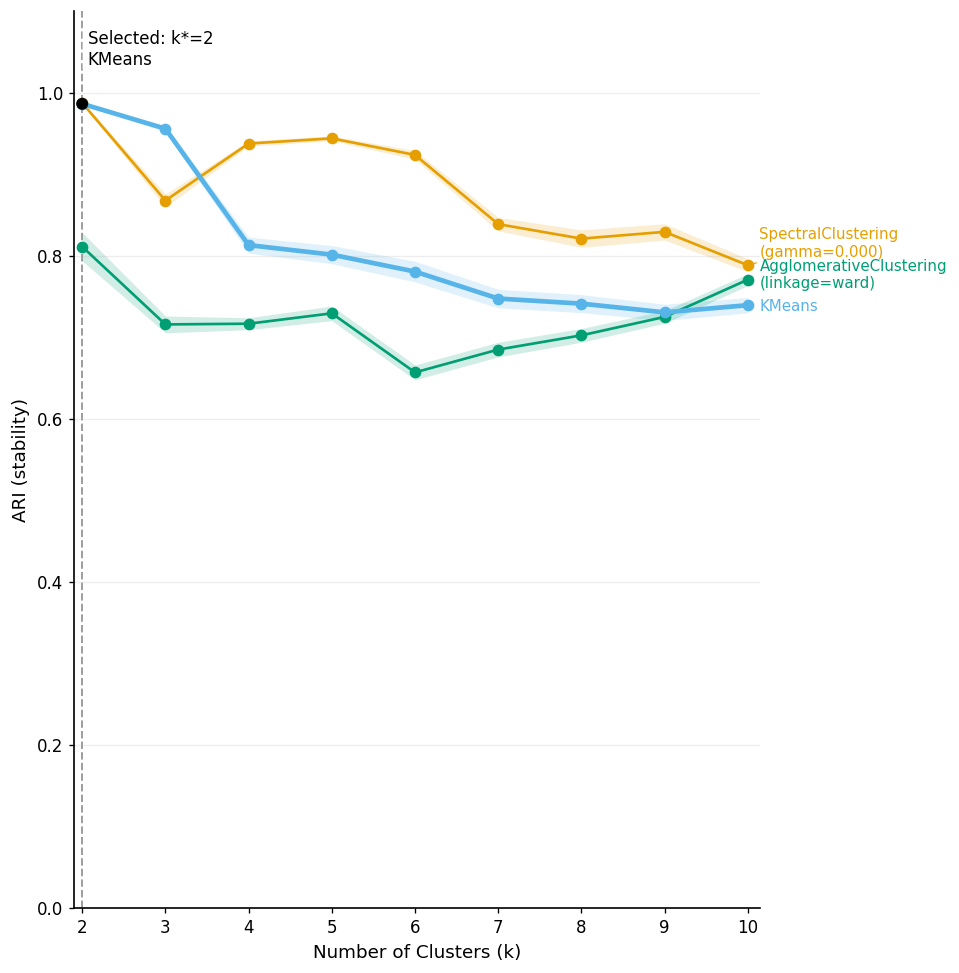

In [40]:
carve.plot_results(measure='ari_stability', rule='1se', interactive=False)

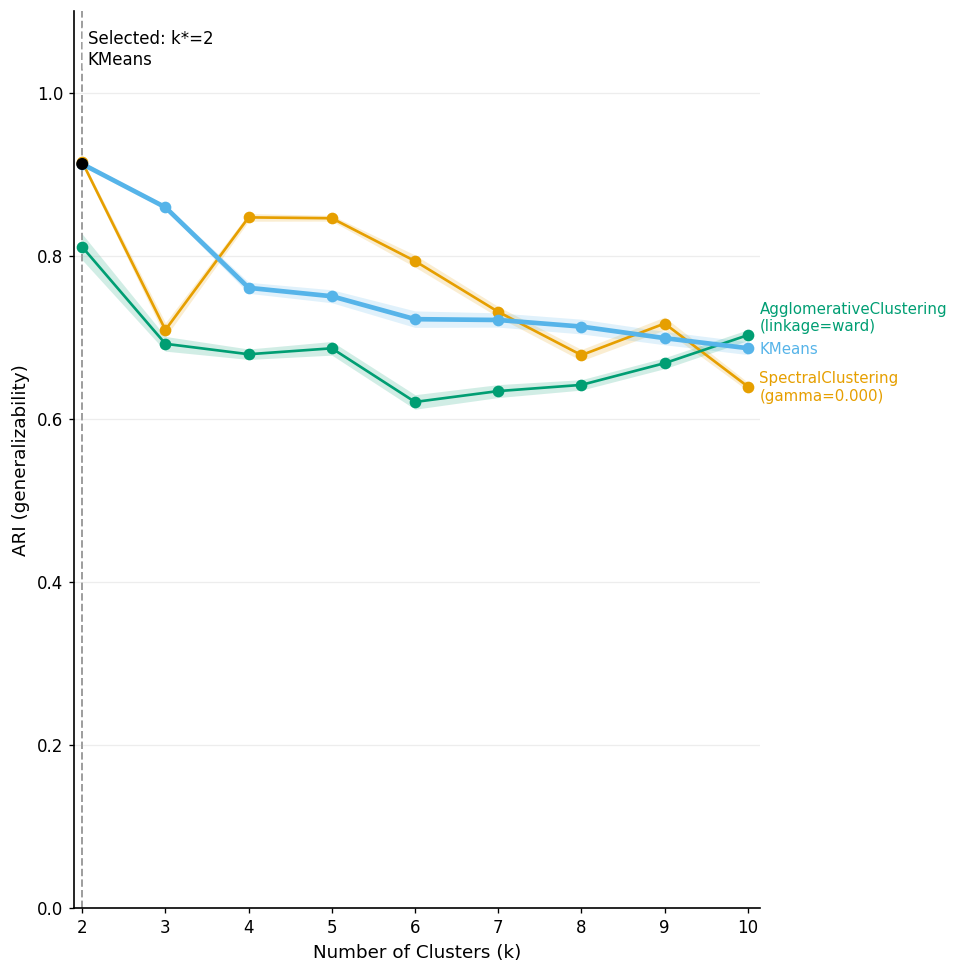

In [41]:
carve.plot_results(measure='ari_generalizability', rule='1se', interactive=False)

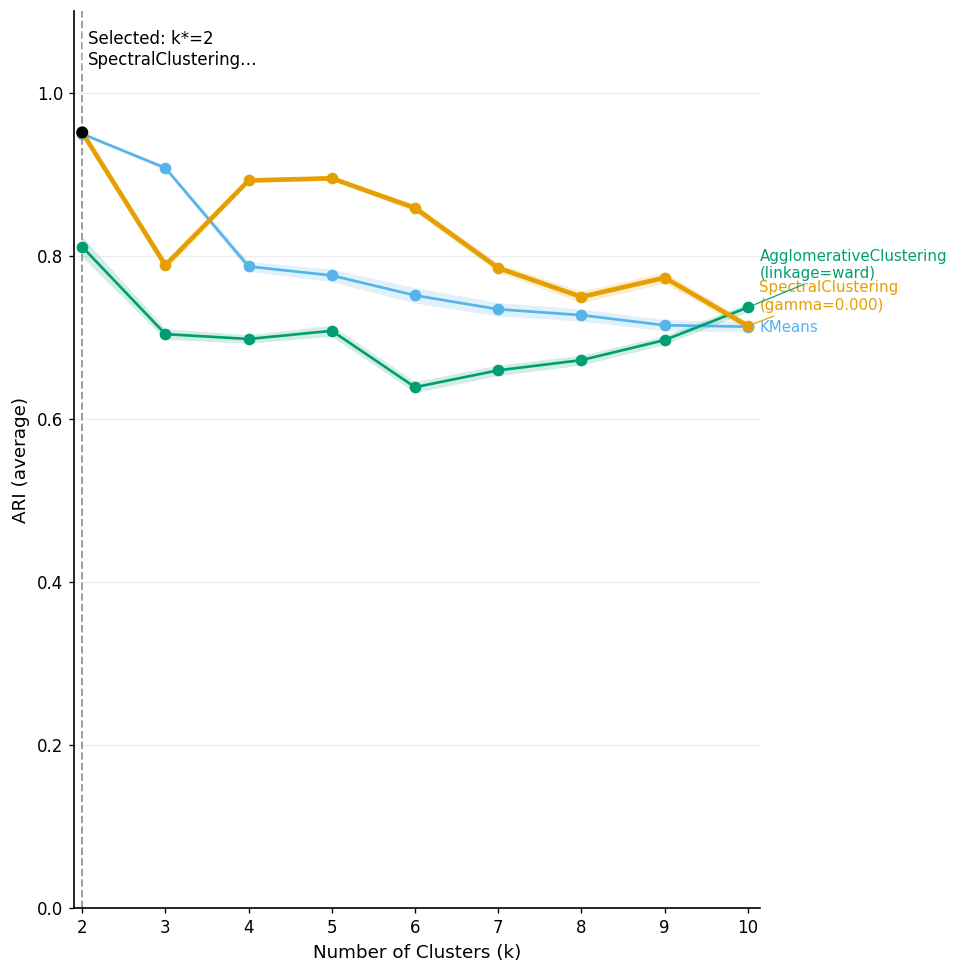

In [42]:
carve.plot_results(measure='ari_average', rule='1se', interactive=False)

In [ ]:
carve.plot_consensus_matrix(measure='generalizability', k=4, rule='1se')

In [44]:
carve.plot_clustering(k=4, measure='generalizability', rule='1se', interactive=False)

ValueError: invalid literal for int() with base 10: 'd0'

In [44]:
# pip if needed:
# %pip install -q plotly kaleido

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

def _unique_in_order(x):
    seen = set()
    out = []
    for v in x:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out

def _hex_to_rgba(hex_color, a=0.35):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{a})"

def alluvial_compare(
    y_true,
    left_labels,
    right_labels,
    left_title="CARVE (spectral)",
    right_title="silhouette (agg/ward)",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
    node_pad=20,
    node_thickness=18,
    font_size=14,
    height=600,
    width=1200,
):
    # --- coerce to strings for clean labeling ---
    y_true = pd.Series(y_true).astype(str).to_numpy()
    left_labels = pd.Series(left_labels).astype(int).to_numpy()
    right_labels = pd.Series(right_labels).astype(int).to_numpy()

    n = len(y_true)
    assert len(left_labels) == n and len(right_labels) == n, "length mismatch"

    # --- order true labels by first appearance (closest to how people expect them) ---
    true_order = _unique_in_order(y_true)

    # --- order clusters numerically, show as 1..K ---
    left_order = sorted(np.unique(left_labels))
    right_order = sorted(np.unique(right_labels))

    # --- colors: assign a stable color per TRUE label ---
    cmap = plt.get_cmap(palette_name)
    true_colors = {lab: "#{:02x}{:02x}{:02x}".format(
        int(255*cmap(i % cmap.N)[0]),
        int(255*cmap(i % cmap.N)[1]),
        int(255*cmap(i % cmap.N)[2]),
    ) for i, lab in enumerate(true_order)}

    # --- helper: compute purity + share and dominant true label per predicted cluster ---
    def cluster_stats(pred):
        df = pd.DataFrame({"pred": pred, "true": y_true})
        ct = pd.crosstab(df["pred"], df["true"]).reindex(index=sorted(df["pred"].unique()), columns=true_order, fill_value=0)
        sizes = ct.sum(axis=1).to_numpy()
        shares = sizes / n
        dom_true = ct.idxmax(axis=1).to_numpy()
        purities = (ct.max(axis=1).to_numpy() / np.maximum(sizes, 1))
        return ct, sizes, shares, dom_true, purities

    ct_left, _, share_left, dom_left, pur_left = cluster_stats(left_labels)
    ct_right, _, share_right, dom_right, pur_right = cluster_stats(right_labels)

    # --- node labels (match screenshot style: big purity %, then share %) ---
    left_node_labels = []
    left_node_colors = []
    for i, k in enumerate(left_order):
        purity = pur_left[i]
        share = share_left[i]
        left_node_labels.append(f"{k+1}<br>{purity*100:.0f}%<br>{share*100:.0f}%")
        left_node_colors.append(true_colors[dom_left[i]])

    true_node_labels = [lab for lab in true_order]
    true_node_colors = [true_colors[lab] for lab in true_order]

    right_node_labels = []
    right_node_colors = []
    for i, k in enumerate(right_order):
        purity = pur_right[i]
        share = share_right[i]
        right_node_labels.append(f"{k+1}<br>{purity*100:.0f}%<br>{share*100:.0f}%")
        right_node_colors.append(true_colors[dom_right[i]])

    # --- node indexing ---
    nL = len(left_order)
    nT = len(true_order)
    nR = len(right_order)

    idx_left = {k: i for i, k in enumerate(left_order)}
    idx_true = {lab: nL + i for i, lab in enumerate(true_order)}
    idx_right = {k: nL + nT + i for i, k in enumerate(right_order)}

    # --- links: left -> true and true -> right, colored by TRUE label ---
    sources = []
    targets = []
    values = []
    colors = []

    # left -> true
    for k in left_order:
        for lab in true_order:
            v = int(ct_left.loc[k, lab]) if (k in ct_left.index and lab in ct_left.columns) else 0
            if v > 0:
                sources.append(idx_left[k])
                targets.append(idx_true[lab])
                values.append(v)
                colors.append(_hex_to_rgba(true_colors[lab], link_alpha))

    # true -> right
    ct_tr = pd.crosstab(pd.Series(y_true, name="true"), pd.Series(right_labels, name="pred")).reindex(index=true_order, columns=right_order, fill_value=0)
    for lab in true_order:
        for k in right_order:
            v = int(ct_tr.loc[lab, k])
            if v > 0:
                sources.append(idx_true[lab])
                targets.append(idx_right[k])
                values.append(v)
                colors.append(_hex_to_rgba(true_colors[lab], link_alpha))

    # --- fixed 3-column layout (x positions), evenly spaced y positions per column ---
    def col_positions(m, top=0.02, bottom=0.98):
        if m == 1:
            return [0.5]
        return list(np.linspace(top, bottom, m))

    x = ([0.0]*nL) + ([0.5]*nT) + ([1.0]*nR)
    y = (col_positions(nL)) + (col_positions(nT)) + (col_positions(nR))

    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=node_pad,
            thickness=node_thickness,
            line=dict(color="rgba(0,0,0,0.25)", width=0.5),
            label=left_node_labels + true_node_labels + right_node_labels,
            color=left_node_colors + true_node_colors + right_node_colors,
            x=x,
            y=y,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
        )
    ))

    fig.update_layout(
        font=dict(size=font_size, family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=width,
        height=height,
        margin=dict(l=40, r=40, t=60, b=20),
        annotations=[
            dict(x=0.0, y=1.08, xref="paper", yref="paper", text=left_title, showarrow=False, font=dict(size=font_size+2)),
            dict(x=0.5, y=1.08, xref="paper", yref="paper", text=true_title, showarrow=False, font=dict(size=font_size+2)),
            dict(x=1.0, y=1.08, xref="paper", yref="paper", text=right_title, showarrow=False, font=dict(size=font_size+2)),
        ],
    )
    return fig


In [ ]:
# Agglomerative k=4 (Ward) –– as suggested by silhouette 
agg_labels = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_sub) 

# Spectral, k=7 –– as suggested by CARVE generalizability 
spectral_labels = SpectralClustering(n_clusters=7, gamma=gamma_quantiles_approx(X_sub, qs=(0.50,), random_state=RANDOM_SEED)[0]).fit_predict(X_sub)

fig = alluvial_compare(
    y_true=y_sub,
    left_labels=spectral_labels,   # CARVE choice
    right_labels=agg_labels,       # silhouette choice
    left_title="CARVE (spectral)",
    right_title="silhouette (agg/ward)",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
)

fig.show()


---